In [ ]:
!pip install matplotlib
!pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns



In [2]:
file_path = "../transactions.parquet"
# open dataset
df = pd.read_parquet(file_path, engine='pyarrow')
print("Read file")

Read file


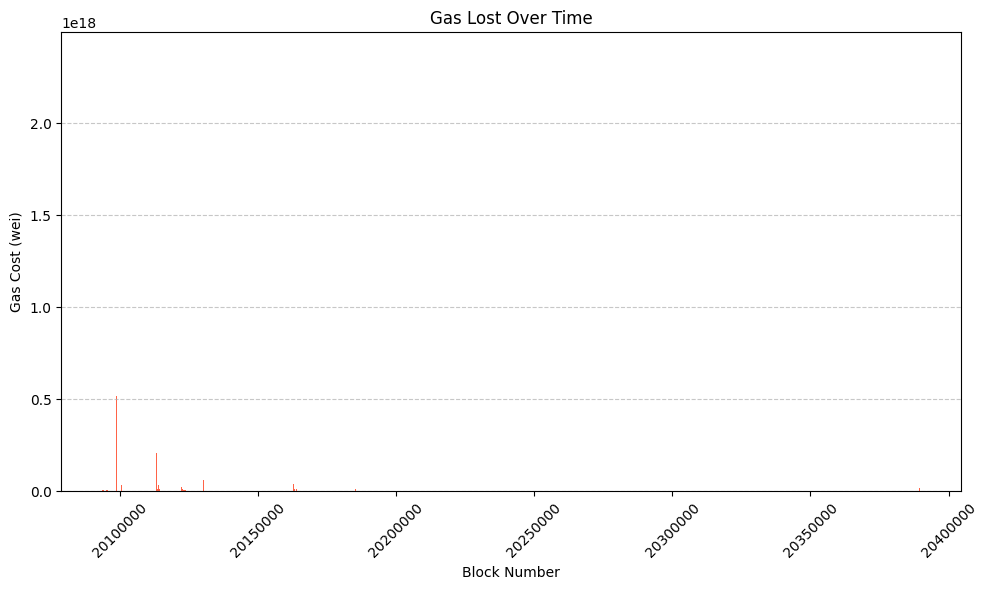

In [3]:
def plot_gas_lost_per_block(df, rolling_window=50):
    out_of_gas_df = df
    out_of_gas_df.loc[:, "gas_cost"] = out_of_gas_df["gas"] * out_of_gas_df["gas_price"]
    gas_lost_by_block = out_of_gas_df.groupby("block_number")["gas_cost"].sum().sort_index()
    gas_lost_smoothed = gas_lost_by_block.rolling(window=rolling_window, min_periods=1).mean()

    plt.figure(figsize=(10, 6), dpi=100)
    plt.ylim(0, gas_lost_smoothed.max() * 1.1)
    plt.bar(gas_lost_smoothed.index, gas_lost_smoothed.values, color='tomato', width=1.0)

    plt.title("Gas Lost Over Time")
    plt.xlabel("Block Number")
    plt.ylabel("Gas Cost (wei)")

    # Ensure full block numbers are displayed
    plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    plt.xticks(rotation=45)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_gas_lost_per_block(df)

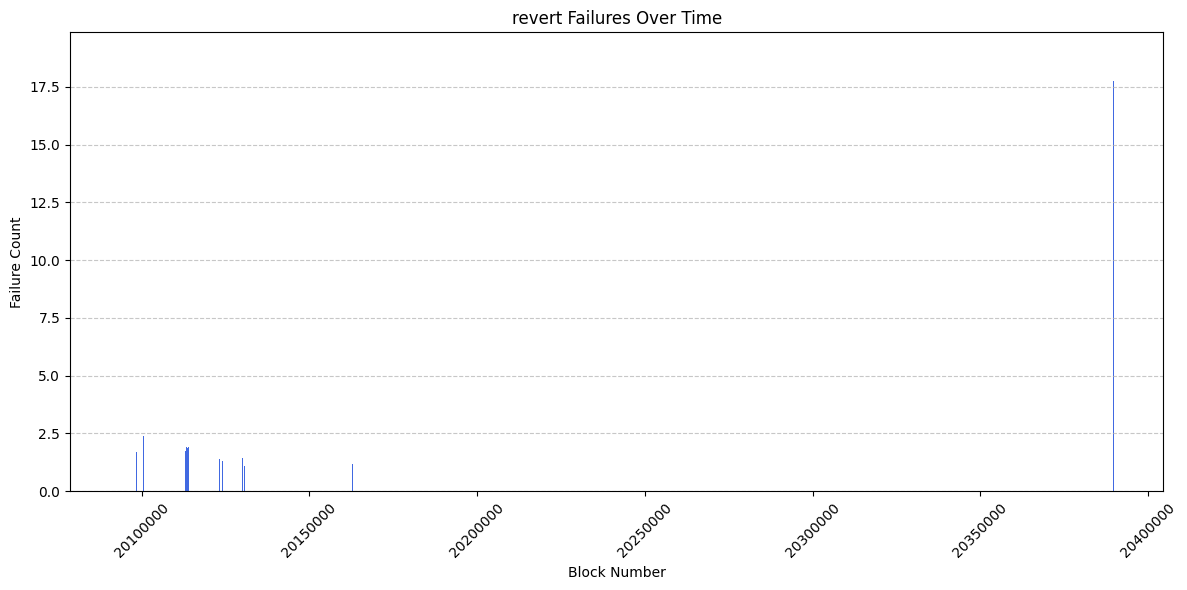

In [34]:
def plot_invariant_count(df, invariant, rolling_window=50):
    df = df[df["failure_invariant"].str.contains(invariant, case=False, na=False)]
    failures_by_block = df.groupby("block_number").size().sort_index()
    failures_smoothed = failures_by_block.rolling(window=rolling_window, min_periods=1).mean()

    plt.figure(figsize=(12, 6))
    plt.bar(failures_smoothed.index, failures_smoothed.values, color='royalblue', width=1.0)

    plt.title(f"{invariant} Failures Over Time")
    plt.xlabel("Block Number")
    plt.ylabel("Failure Count")

    plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    plt.xticks(rotation=45)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
plot_invariant_count(df, "revert")


C:\Users\Melis\AppData\Local\Temp\ipykernel_22924\1621894648.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='failed_count', y='from_address', data=from_address_df, ax=axes[0], palette='Blues_d')
C:\Users\Melis\AppData\Local\Temp\ipykernel_22924\1621894648.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='failed_count', y='to_address', data=to_address_df, ax=axes[1], palette='Reds_d')


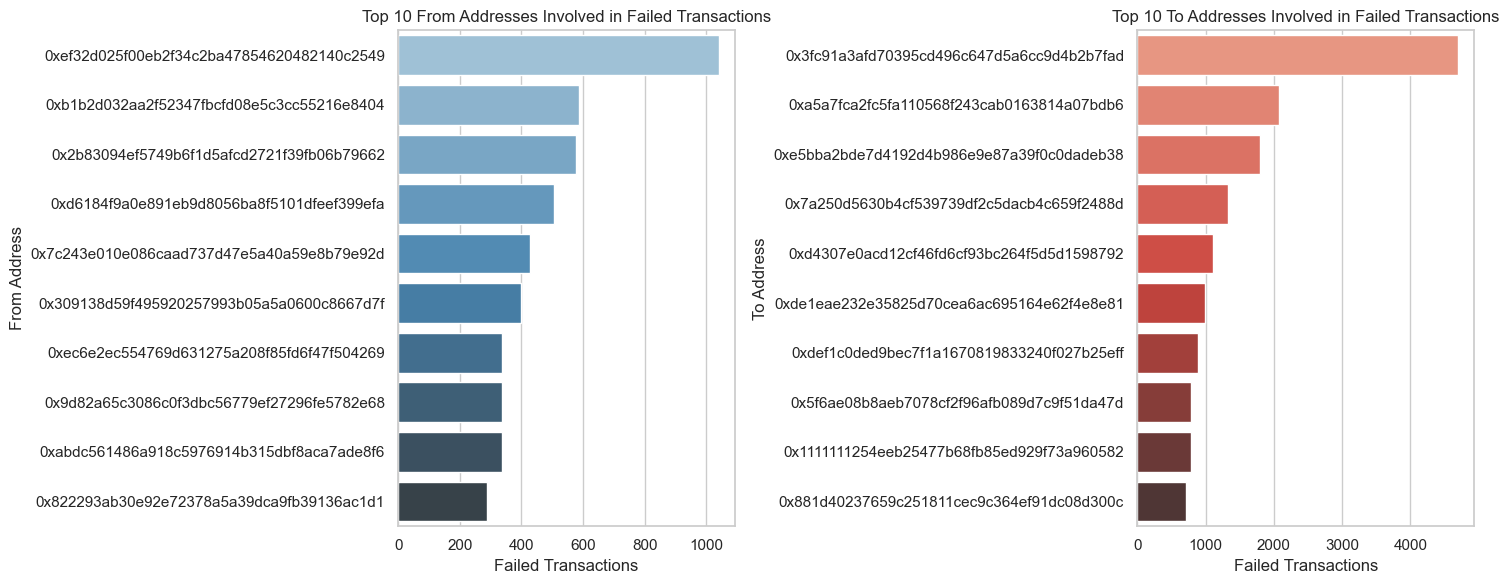

In [37]:
def plot_most_common_transactions(df):
    from_address_counts = df['from_address'].value_counts().head(10)  # Top 10 'from_address'
    to_address_counts = df['to_address'].value_counts().head(10)  # Top 10 'to_address'

    from_address_df = from_address_counts.reset_index()
    from_address_df.columns = ['from_address', 'failed_count']

    to_address_df = to_address_counts.reset_index()
    to_address_df.columns = ['to_address', 'failed_count']

    sns.set(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.barplot(x='failed_count', y='from_address', data=from_address_df, ax=axes[0], palette='Blues_d')
    axes[0].set_title('Top 10 From Addresses Involved in Failed Transactions')
    axes[0].set_xlabel('Failed Transactions')
    axes[0].set_ylabel('From Address')

    sns.barplot(x='failed_count', y='to_address', data=to_address_df, ax=axes[1], palette='Reds_d')
    axes[1].set_title('Top 10 To Addresses Involved in Failed Transactions')
    axes[1].set_xlabel('Failed Transactions')
    axes[1].set_ylabel('To Address')

    # Adjust layout to avoid overlapping labels
    plt.tight_layout()

    # Show the plot
    plt.show()

plot_most_common_transactions(df)

C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\3371443807.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='failed_count', y='failure_invariant', data=invariant_df, palette='viridis')


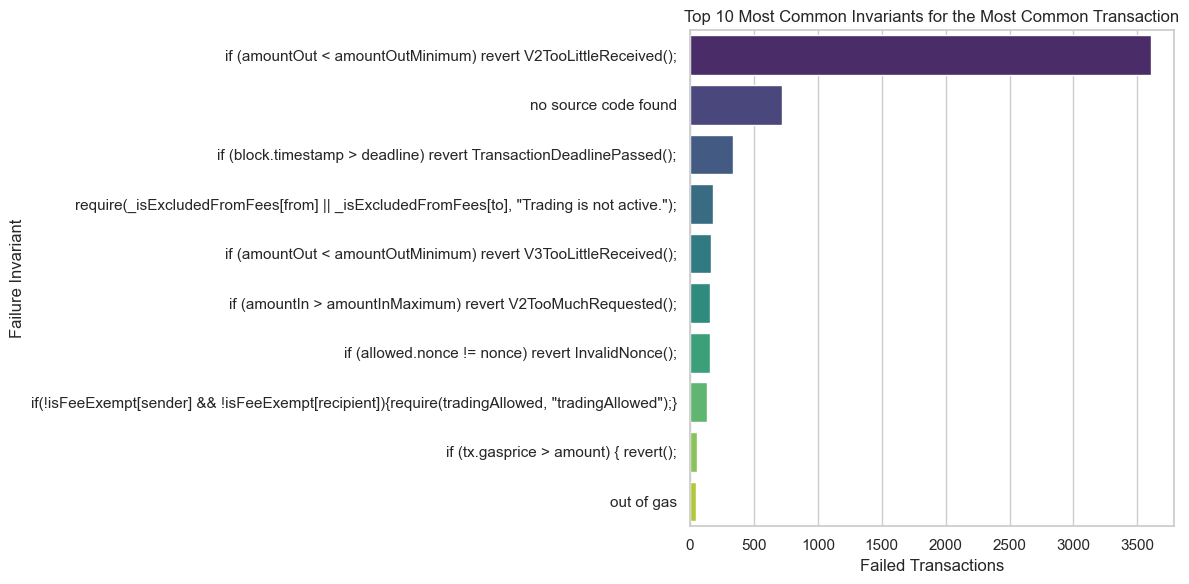

In [ ]:
def plot_most_common_invariants_for_top_transactions(df, top_n=10):
    # Find the 10 most common from_address and to_address combinations
    from_address_counts = df['from_address'].value_counts().head(1)
    to_address_counts = df['to_address'].value_counts().head(1)

    # Get the most common addresses
    top_from_addresses = from_address_counts.index.tolist()
    top_to_addresses = to_address_counts.index.tolist()

    # Filter the dataframe to include only these top addresses
    filtered_df = df[df['from_address'].isin(top_from_addresses) | df['to_address'].isin(top_to_addresses)]

    # Count the occurrences of each failure_invariant in the filtered data
    invariant_counts = filtered_df['failure_invariant'].value_counts().head(top_n)

    # Convert the counts to a DataFrame for easier plotting
    invariant_df = invariant_counts.reset_index()
    invariant_df.columns = ['failure_invariant', 'failed_count']

    # Set seaborn style
    sns.set(style="whitegrid")

    # Plot the most common invariants for the top 10 transactions
    plt.figure(figsize=(12, 6))
    sns.barplot(x='failed_count', y='failure_invariant', data=invariant_df, palette='viridis')

    plt.title(f'Top {top_n} Most Common Invariants for the Most Common Transaction')
    plt.xlabel('Failed Transactions')
    plt.ylabel('Failure Invariant')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Show the plot
    plt.show()

plot_most_common_invariants_for_top_transactions(df)

C:\Users\Melis\AppData\Local\Temp\ipykernel_29020\265447992.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='failed_count', y='failure_invariant', data=invariant_df, palette='viridis')


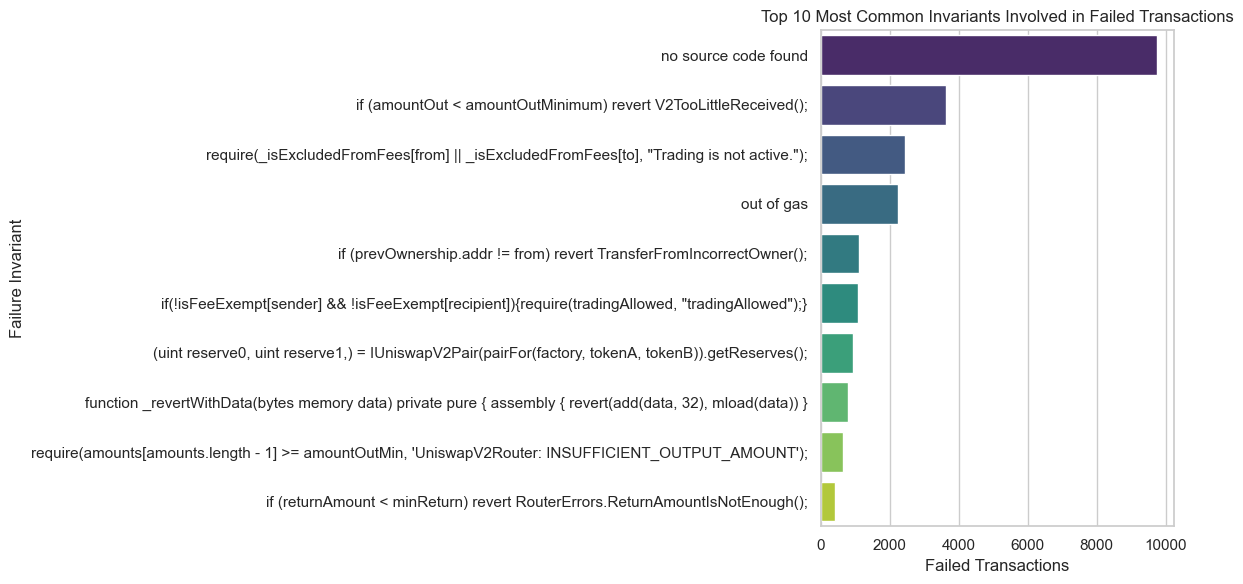

In [4]:
def plot_most_common_invariants(df, top_n=10):
    # Count the occurrences of each unique failure_invariant
    invariant_counts = df['failure_invariant'].value_counts().head(top_n)  # Top 'n' invariants

    # Convert the counts to a DataFrame for easier plotting
    invariant_df = invariant_counts.reset_index()
    invariant_df.columns = ['failure_invariant', 'failed_count']

    # Set seaborn style
    sns.set(style="whitegrid")

    # Plot the most common invariants involved in failed transactions
    plt.figure(figsize=(12, 6))
    sns.barplot(x='failed_count', y='failure_invariant', data=invariant_df, palette='viridis')

    plt.title(f'Top {top_n} Most Common Invariants Involved in Failed Transactions')
    plt.xlabel('Failed Transactions')
    plt.ylabel('Failure Invariant')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Show the plot
    plt.show()

plot_most_common_invariants(df)

C:\Users\Melis\AppData\Local\Temp\ipykernel_22924\93568371.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_failure_counts.values, y=top_failure_counts.index, palette="viridis")


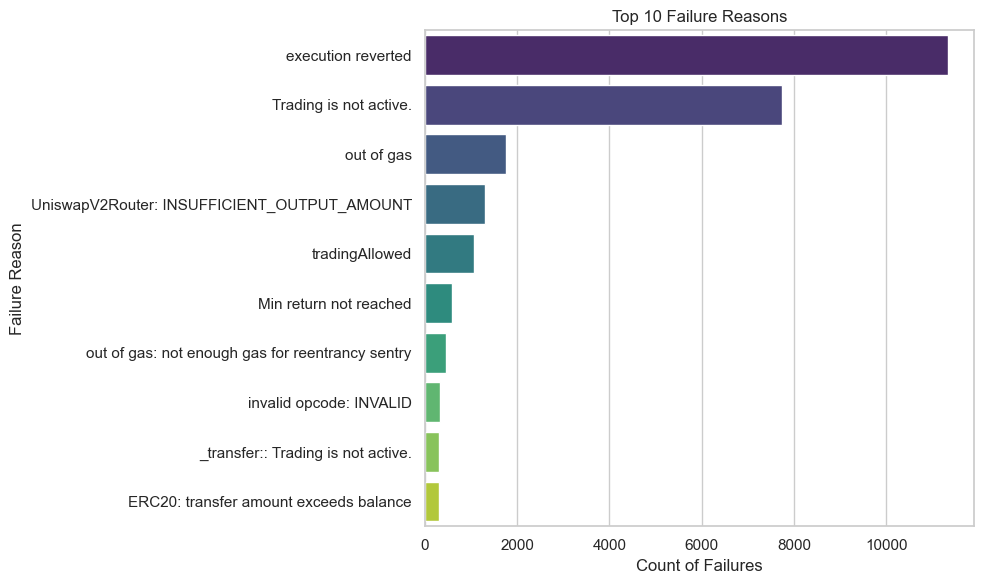

In [39]:
def failure_reason_frequency(df):
    failure_counts = df["failure_reason"].value_counts()
    top_failure_counts = failure_counts.head(10)
    
    # Set the style for the plot
    sns.set(style="whitegrid")
    
    # Create a bar plot for the top failure reasons
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_failure_counts.values, y=top_failure_counts.index, palette="viridis")
    
    # Set plot labels and title
    plt.title(f'Top 10 Failure Reasons')
    plt.xlabel('Count of Failures')
    plt.ylabel('Failure Reason')
    
    # Display the plot
    plt.tight_layout()
    plt.show()

failure_reason_frequency(df)


In [ ]:
def gas_loss_specifics(df, rolling_window=50):
    # Filter out rows where the failure reason contains "out of gas"
    out_of_gas_df = df[df['failure_reason'].str.contains("out of gas", case=False, na=False)]
    
    if out_of_gas_df.empty:
        print("No 'out of gas' transactions found. Here's a sample of your failure reasons:")
        print(df['failure_reason'].value_counts().head(10))  # Check the top failure reasons
        return
    
    # Use .loc to safely assign the "gas_cost" column
    out_of_gas_df.loc[:, "gas_cost"] = out_of_gas_df["gas"] * out_of_gas_df["gas_price"]
    
    # Group by block number and calculate gas cost per block
    gas_lost_by_block = out_of_gas_df.groupby("block_number")["gas_cost"].sum().sort_index()
    gas_lost_smoothed = gas_lost_by_block.rolling(window=rolling_window, min_periods=1).mean()

    # Plot the gas lost per block
    plt.figure(figsize=(12, 7), dpi=100)
    plt.ylim(0, gas_lost_smoothed.max() * 1.1)
    plt.bar(gas_lost_smoothed.index, gas_lost_smoothed.values, color='tomato', width=1.0)

    # Title and labels
    plt.title("Gas Lost Over Time (Failed Transactions)")
    plt.xlabel("Block Number")
    plt.ylabel("Gas Cost (wei)")
    
    # Formatting for the x-axis (Block Numbers)
    plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    plt.xticks(rotation=45)

    # Grid and layout
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Additional Analysis: Gas usage patterns (average, median, distribution)
    print("\nGas Usage Patterns (for Failed Transactions):")
    print(f"Average Gas: {out_of_gas_df['gas'].mean():,.0f} wei")
    print(f"Median Gas: {out_of_gas_df['gas'].median():,.0f} wei")
    print(f"Average Gas Price: {out_of_gas_df['gas_price'].mean():,.0f} wei")
    print(f"Median Gas Price: {out_of_gas_df['gas_price'].median():,.0f} wei")
    
    # Distribution of Gas usage
    plt.figure(figsize=(12, 7))
    sns.histplot(out_of_gas_df['gas'], color='blue', label='Gas Used', kde=True, stat='density', linewidth=1)
    sns.histplot(out_of_gas_df['gas_price'], color='green', label='Gas Price', kde=True, stat='density', linewidth=1)
    plt.title("Gas Usage and Gas Price Distribution for Failed Transactions")
    plt.xlabel("Gas / Gas Price (wei)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Check if gas was underpriced (lower 25% of gas price)
    underpriced_gas = out_of_gas_df[out_of_gas_df['gas_price'] < out_of_gas_df['gas_price'].quantile(0.25)]

    print(f"\nTransactions where gas was underpriced (lower 25% of gas price): {underpriced_gas.shape[0]}")

gas_loss_specifics(df)